# Klasifikasi Biner: Non-Recyclable vs Recyclable

Notebook ini melakukan klasifikasi gambar sampah ke dalam 2 kategori:
- **Non-Recyclable**: Sampah yang tidak dapat didaur ulang (ceramic, diapers, plastic bags/wrappers, sanitary napkin, styrofoam)
- **Recyclable**: Sampah yang dapat didaur ulang (cans, glass containers, paper products, plastic bottles)

**Pendekatan:**
- Transfer Learning — MobileNetV2 (pretrained ImageNet)
- Base model di-freeze, hanya classification head yang dilatih (single-phase)
- Cocok untuk dataset kecil (~1300 gambar) agar tidak overfitting
- Augmentasi agresif + Test-Time Augmentation (TTA)

## 1. Import Libraries

In [1]:
import os
import random
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.losses import BinaryCrossentropy
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from PIL import Image

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

c:\Users\Bisma\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\Bisma\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\Bisma\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framewo

TensorFlow version: 2.20.0
GPU available: []


## 2. Konfigurasi

In [2]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 50  # Single phase, EarlyStopping akan berhenti lebih awal
LEARNING_RATE = 1e-3

# Path dataset
NON_RECYCLABLE_DIR = r"C:\Users\Bisma\Downloads\Documents\tanin\datasets\waste_raw\Non-Recyclable\Non-Recyclable"
RECYCLABLE_DIR = r"C:\Users\Bisma\Downloads\Documents\tanin\datasets\waste_raw\Recyclable\Recyclable"

categories = ['Non-Recyclable', 'Recyclable']

print("Konfigurasi:")
print(f"  Image Size : {IMG_SIZE}")
print(f"  Batch Size : {BATCH_SIZE}")
print(f"  Max Epochs : {EPOCHS}")
print(f"  LR         : {LEARNING_RATE}")
print(f"  Categories : {categories}")

Konfigurasi:
  Image Size : (224, 224)
  Batch Size : 32
  Max Epochs : 50
  LR         : 0.001
  Categories : ['Non-Recyclable', 'Recyclable']


## 3. Kumpulkan & Validasi Data

In [3]:
def validate_image(filepath):
    """Cek apakah file gambar valid dan tidak corrupt."""
    try:
        img = Image.open(filepath)
        img.verify()
        return True
    except Exception:
        return False

def collect_images(base_dir, label):
    """Kumpulkan semua path gambar dari folder dan subfolder."""
    valid_ext = {'.jpg', '.jpeg', '.png', '.bmp', '.gif', '.webp'}
    data = []
    for img_path in Path(base_dir).rglob('*'):
        if img_path.is_file() and img_path.suffix.lower() in valid_ext:
            data.append({'filename': str(img_path), 'class': label})
    return data

# Kumpulkan data
print("Mengumpulkan data gambar...")
all_data = []
all_data.extend(collect_images(NON_RECYCLABLE_DIR, 'Non-Recyclable'))
all_data.extend(collect_images(RECYCLABLE_DIR, 'Recyclable'))
df = pd.DataFrame(all_data)

print(f"Total gambar ditemukan: {len(df)}")
print(df['class'].value_counts())

Mengumpulkan data gambar...
Total gambar ditemukan: 1309
class
Recyclable        662
Non-Recyclable    647
Name: count, dtype: int64


In [4]:
# Validasi — buang gambar corrupt
print("\nMemvalidasi gambar...")
valid_mask = df['filename'].apply(validate_image)
corrupt_count = (~valid_mask).sum()
df = df[valid_mask].reset_index(drop=True)

print(f"Gambar corrupt: {corrupt_count}")
print(f"Gambar valid  : {len(df)}")
print(df['class'].value_counts())


Memvalidasi gambar...


c:\Users\Bisma\AppData\Local\Programs\Python\Python313\Lib\site-packages\PIL\TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Gambar corrupt: 0
Gambar valid  : 1309
class
Recyclable        662
Non-Recyclable    647
Name: count, dtype: int64


## 4. Visualisasi Distribusi Data

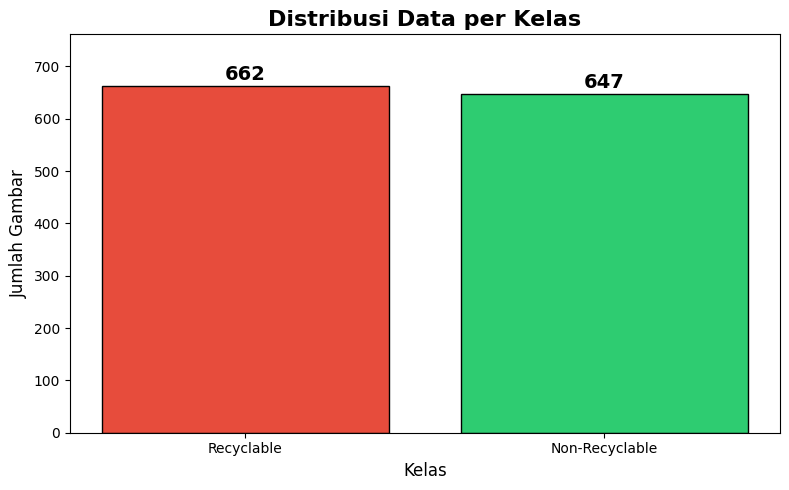

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
counts = df['class'].value_counts()
colors = ['#e74c3c', '#2ecc71']
bars = ax.bar(counts.index, counts.values, color=colors, edgecolor='black')

for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 5,
            str(val), ha='center', va='bottom', fontweight='bold', fontsize=14)

ax.set_title('Distribusi Data per Kelas', fontsize=16, fontweight='bold')
ax.set_xlabel('Kelas', fontsize=12)
ax.set_ylabel('Jumlah Gambar', fontsize=12)
ax.set_ylim(0, max(counts.values) * 1.15)
plt.tight_layout()
plt.savefig('binary_distribusi_data.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Sample Gambar

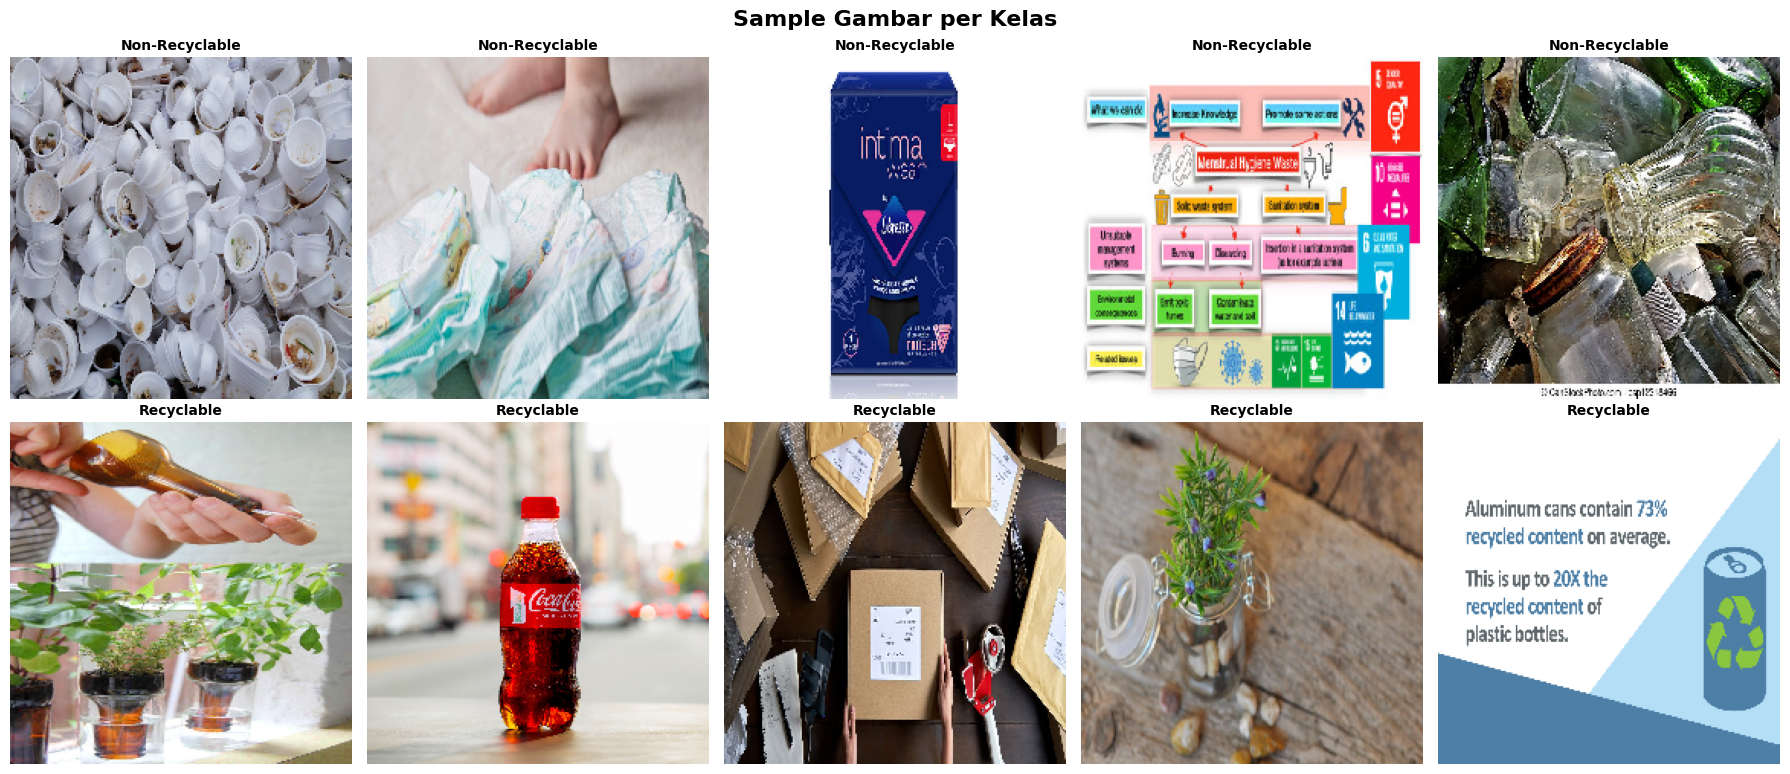

In [6]:
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
for row, cat in enumerate(categories):
    samples = df[df['class'] == cat].sample(n=5, random_state=SEED)
    for col, (_, s) in enumerate(samples.iterrows()):
        ax = axes[row, col]
        try:
            ax.imshow(load_img(s['filename'], target_size=IMG_SIZE))
        except Exception:
            ax.text(0.5, 0.5, 'Error', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(cat, fontsize=10, fontweight='bold')
        ax.axis('off')

plt.suptitle('Sample Gambar per Kelas', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('binary_sample_gambar.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Split Data — 70% Train / 15% Val / 15% Test

In [7]:
train_df, temp_df = train_test_split(
    df, test_size=0.3, random_state=SEED, stratify=df['class']
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, random_state=SEED, stratify=temp_df['class']
)
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

for name, d in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    print(f"{name:5}: {len(d)} gambar — "
          f"NR: {len(d[d['class']=='Non-Recyclable'])}, "
          f"R: {len(d[d['class']=='Recyclable'])}")

Train: 916 gambar — NR: 453, R: 463
Val  : 196 gambar — NR: 97, R: 99
Test : 197 gambar — NR: 97, R: 100


## 7. Data Augmentation & Generators

In [8]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

In [9]:
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df, x_col='filename', y_col='class',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='binary', classes=categories,
    shuffle=True, seed=SEED
)

val_generator = val_test_datagen.flow_from_dataframe(
    dataframe=val_df, x_col='filename', y_col='class',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='binary', classes=categories,
    shuffle=False
)

test_generator = val_test_datagen.flow_from_dataframe(
    dataframe=test_df, x_col='filename', y_col='class',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='binary', classes=categories,
    shuffle=False
)

print(f"\nClass indices: {train_generator.class_indices}")

Found 904 validated image filenames belonging to 2 classes.
Found 193 validated image filenames belonging to 2 classes.
Found 196 validated image filenames belonging to 2 classes.

Class indices: {'Non-Recyclable': 0, 'Recyclable': 1}


c:\Users\Bisma\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\legacy\preprocessing\image.py:920: UserWarning: Found 12 invalid image filename(s) in x_col="filename". These filename(s) will be ignored.
  warnings.warn(
c:\Users\Bisma\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\legacy\preprocessing\image.py:920: UserWarning: Found 3 invalid image filename(s) in x_col="filename". These filename(s) will be ignored.
  warnings.warn(
c:\Users\Bisma\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\legacy\preprocessing\image.py:920: UserWarning: Found 1 invalid image filename(s) in x_col="filename". These filename(s) will be ignored.
  warnings.warn(


## 8. Bangun Model — MobileNetV2 Transfer Learning

- Base model MobileNetV2 pretrained ImageNet — **seluruh base di-freeze**
- Hanya classification head yang dilatih
- Cocok untuk dataset kecil (~1300 gambar) — menghindari overfitting

In [10]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)
base_model.trainable = False  # Freeze seluruh base model

# Classification head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=x)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,427,201 (9.26 MB)

 Trainable params: 166,657 (651.00 KB)

 Non-trainable params: 2,260,544 (8.62 MB)

## 9. Compile & Training

- **Single phase** — tanpa freeze/unfreeze
- LR fixed 1e-3 + ReduceLROnPlateau (turunkan LR saat val_loss stagnan)
- EarlyStopping patience 10 (cukup sabar karena single phase)

In [11]:
model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss=BinaryCrossentropy(label_smoothing=0.05),
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=4,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        'binary_best_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

In [12]:
print("=" * 60)
print("TRAINING: Transfer Learning — MobileNetV2")
print(f"  Base Model    : Frozen (feature extractor)")
print(f"  Trainable head: GAP → BN → Dense(128) → Dropout(0.5) → Sigmoid")
print(f"  Max Epochs    : {EPOCHS}")
print(f"  LR            : {LEARNING_RATE} (+ ReduceLROnPlateau)")
print(f"  EarlyStopping : patience=10")
print("=" * 60)

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=callbacks,
    verbose=1
)

TRAINING: Transfer Learning — MobileNetV2
  Base Model    : Frozen (feature extractor)
  Trainable head: GAP → BN → Dense(128) → Dropout(0.5) → Sigmoid
  Max Epochs    : 50
  LR            : 0.001 (+ ReduceLROnPlateau)
  EarlyStopping : patience=10


c:\Users\Bisma\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50


c:\Users\Bisma\AppData\Local\Programs\Python\Python313\Lib\site-packages\PIL\Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5763 - loss: 0.9211
Epoch 1: val_accuracy improved from None to 0.76166, saving model to binary_best_model.keras
29/29 ━━━━━━━━━━━━━━━━━━━━ 85s 3s/step - accuracy: 0.6582 - loss: 0.7917 - val_accuracy: 0.7617 - val_loss: 0.4906 - learning_rate: 0.0010
Epoch 2/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7366 - loss: 0.6114
Epoch 2: val_accuracy improved from 0.76166 to 0.80829, saving model to binary_best_model.keras
29/29 ━━━━━━━━━━━━━━━━━━━━ 65s 2s/step - accuracy: 0.7544 - loss: 0.5612 - val_accuracy: 0.8083 - val_loss: 0.4540 - learning_rate: 0.0010
Epoch 3/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7924 - loss: 0.5165
Epoch 3: val_accuracy improved from 0.80829 to 0.81347, saving model to binary_best_model.keras
29/29 ━━━━━━━━━━━━━━━━━━━━ 67s 2s/step - accuracy: 0.8175 - loss: 0.4936 - val_accuracy: 0.8135 - val_loss: 0.4482 - learning_rate: 0.0010
Epoch 4/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy:

## 10. Training History

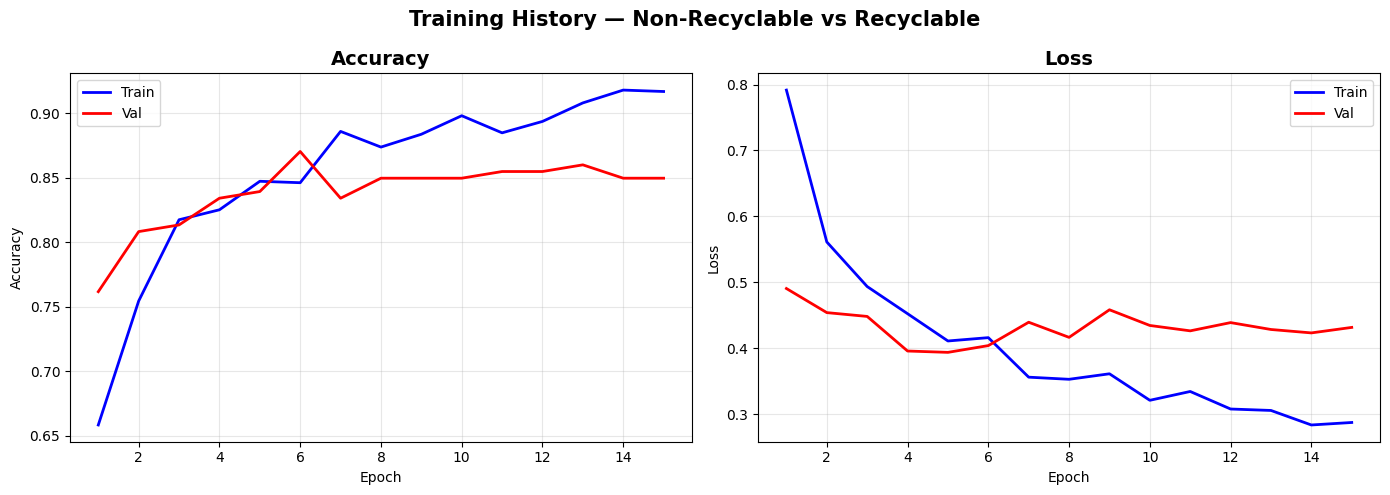

Disimpan: binary_training_history.png


In [13]:
def plot_history(history, save_path='binary_training_history.png'):
    """Plot training & validation accuracy/loss."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    epochs_range = range(1, len(history.history['accuracy']) + 1)

    ax1.plot(epochs_range, history.history['accuracy'], 'b-', label='Train', linewidth=2)
    ax1.plot(epochs_range, history.history['val_accuracy'], 'r-', label='Val', linewidth=2)
    ax1.set_title('Accuracy', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.plot(epochs_range, history.history['loss'], 'b-', label='Train', linewidth=2)
    ax2.plot(epochs_range, history.history['val_loss'], 'r-', label='Val', linewidth=2)
    ax2.set_title('Loss', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.suptitle('Training History — Non-Recyclable vs Recyclable', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Disimpan: {save_path}")

plot_history(history)

## 11. Evaluasi pada Test Set (dengan TTA)

In [14]:
def evaluate_with_tta(model, test_df, categories, img_size=(224, 224),
                      n_augments=5, batch_size=32):
    """Evaluasi dengan Test-Time Augmentation."""
    orig_gen = ImageDataGenerator(rescale=1./255)
    tta_gen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=15,
        width_shift_range=0.1,
        height_shift_range=0.1,
        zoom_range=0.1,
        horizontal_flip=True,
        brightness_range=[0.9, 1.1]
    )

    # Prediksi original
    orig_flow = orig_gen.flow_from_dataframe(
        dataframe=test_df, x_col='filename', y_col='class',
        target_size=img_size, batch_size=batch_size,
        class_mode='binary', classes=categories, shuffle=False
    )
    preds_sum = model.predict(orig_flow, steps=len(orig_flow), verbose=0).flatten()

    # Prediksi augmented
    for _ in range(n_augments):
        aug_flow = tta_gen.flow_from_dataframe(
            dataframe=test_df, x_col='filename', y_col='class',
            target_size=img_size, batch_size=batch_size,
            class_mode='binary', classes=categories, shuffle=False
        )
        preds_sum += model.predict(aug_flow, steps=len(aug_flow), verbose=0).flatten()

    preds_avg = preds_sum / (1 + n_augments)
    y_pred = (preds_avg >= 0.5).astype(int)
    y_true = orig_flow.classes
    return y_true, y_pred, preds_avg

In [15]:
print("Evaluasi dengan Test-Time Augmentation (5x)...")
y_true, y_pred, y_proba = evaluate_with_tta(model, test_df, categories, IMG_SIZE)

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT (TTA)")
print("=" * 60)
print(classification_report(y_true, y_pred, target_names=categories))

acc = accuracy_score(y_true, y_pred)
print(f"Overall Accuracy (TTA): {acc:.4f} ({acc*100:.2f}%)")

for i, cat in enumerate(categories):
    mask = y_true == i
    cat_acc = (y_pred[mask] == y_true[mask]).mean()
    print(f"  {cat}: {cat_acc:.4f} ({cat_acc*100:.2f}%)")

Evaluasi dengan Test-Time Augmentation (5x)...
Found 196 validated image filenames belonging to 2 classes.


c:\Users\Bisma\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\legacy\preprocessing\image.py:920: UserWarning: Found 1 invalid image filename(s) in x_col="filename". These filename(s) will be ignored.
  warnings.warn(
c:\Users\Bisma\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
c:\Users\Bisma\AppData\Local\Programs\Python\Python313\Lib\site-packages\PIL\TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Found 196 validated image filenames belonging to 2 classes.


c:\Users\Bisma\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\legacy\preprocessing\image.py:920: UserWarning: Found 1 invalid image filename(s) in x_col="filename". These filename(s) will be ignored.
  warnings.warn(
c:\Users\Bisma\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
c:\Users\Bisma\AppData\Local\Programs\Python\Python313\Lib\site-packages\PIL\TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Found 196 validated image filenames belonging to 2 classes.


...

c:\Users\Bisma\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\legacy\preprocessing\image.py:920: UserWarning: Found 1 invalid image filename(s) in x_col="filename". These filename(s) will be ignored.
  warnings.warn(
c:\Users\Bisma\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
c:\Users\Bisma\AppData\Local\Programs\Python\Python313\Lib\site-packages\PIL\TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))



CLASSIFICATION REPORT (TTA)
                precision    recall  f1-score   support

Non-Recyclable       0.87      0.87      0.87        97
    Recyclable       0.87      0.87      0.87        99

      accuracy                           0.87       196
     macro avg       0.87      0.87      0.87       196
  weighted avg       0.87      0.87      0.87       196

Overall Accuracy (TTA): 0.8673 (86.73%)


C:\Users\Bisma\AppData\Local\Temp\ipykernel_2740\1742111188.py:14: RuntimeWarning: Mean of empty slice.
  cat_acc = (y_pred[mask] == y_true[mask]).mean()


  Non-Recyclable: nan (nan%)
  Recyclable: nan (nan%)


c:\Users\Bisma\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


## 12. Confusion Matrix

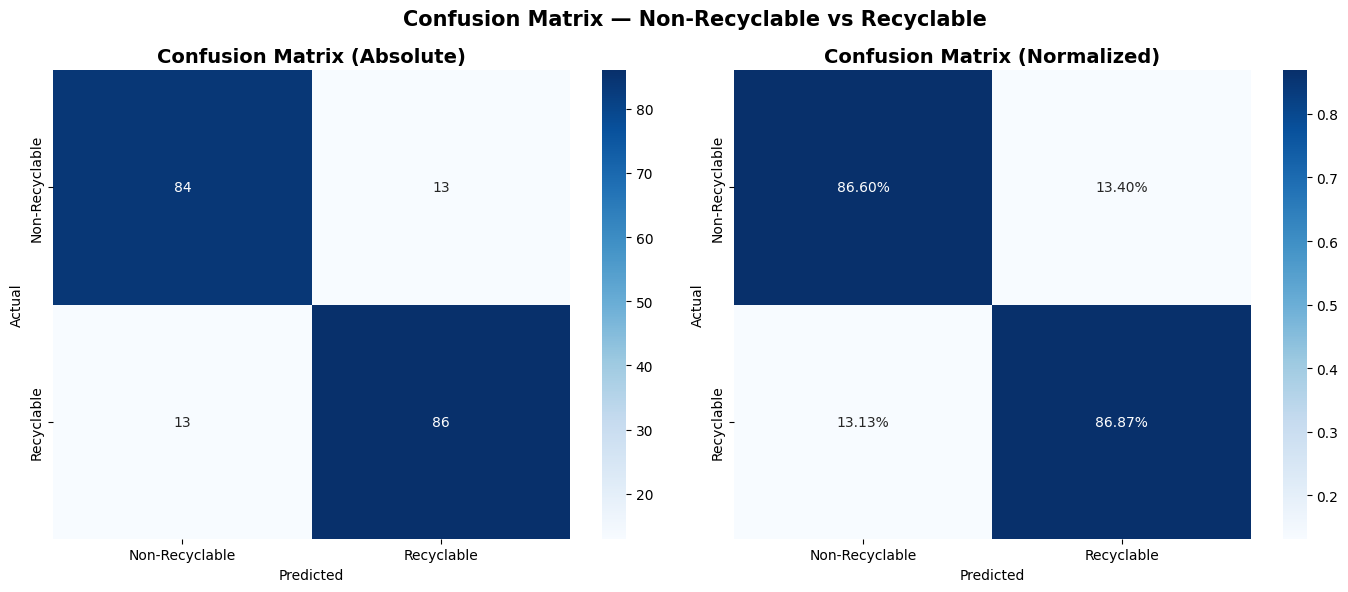

In [16]:
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=categories, yticklabels=categories, ax=ax1)
ax1.set_title('Confusion Matrix (Absolute)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')

sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=categories, yticklabels=categories, ax=ax2)
ax2.set_title('Confusion Matrix (Normalized)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Predicted')
ax2.set_ylabel('Actual')

plt.suptitle('Confusion Matrix — Non-Recyclable vs Recyclable', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('binary_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. Sample Prediksi

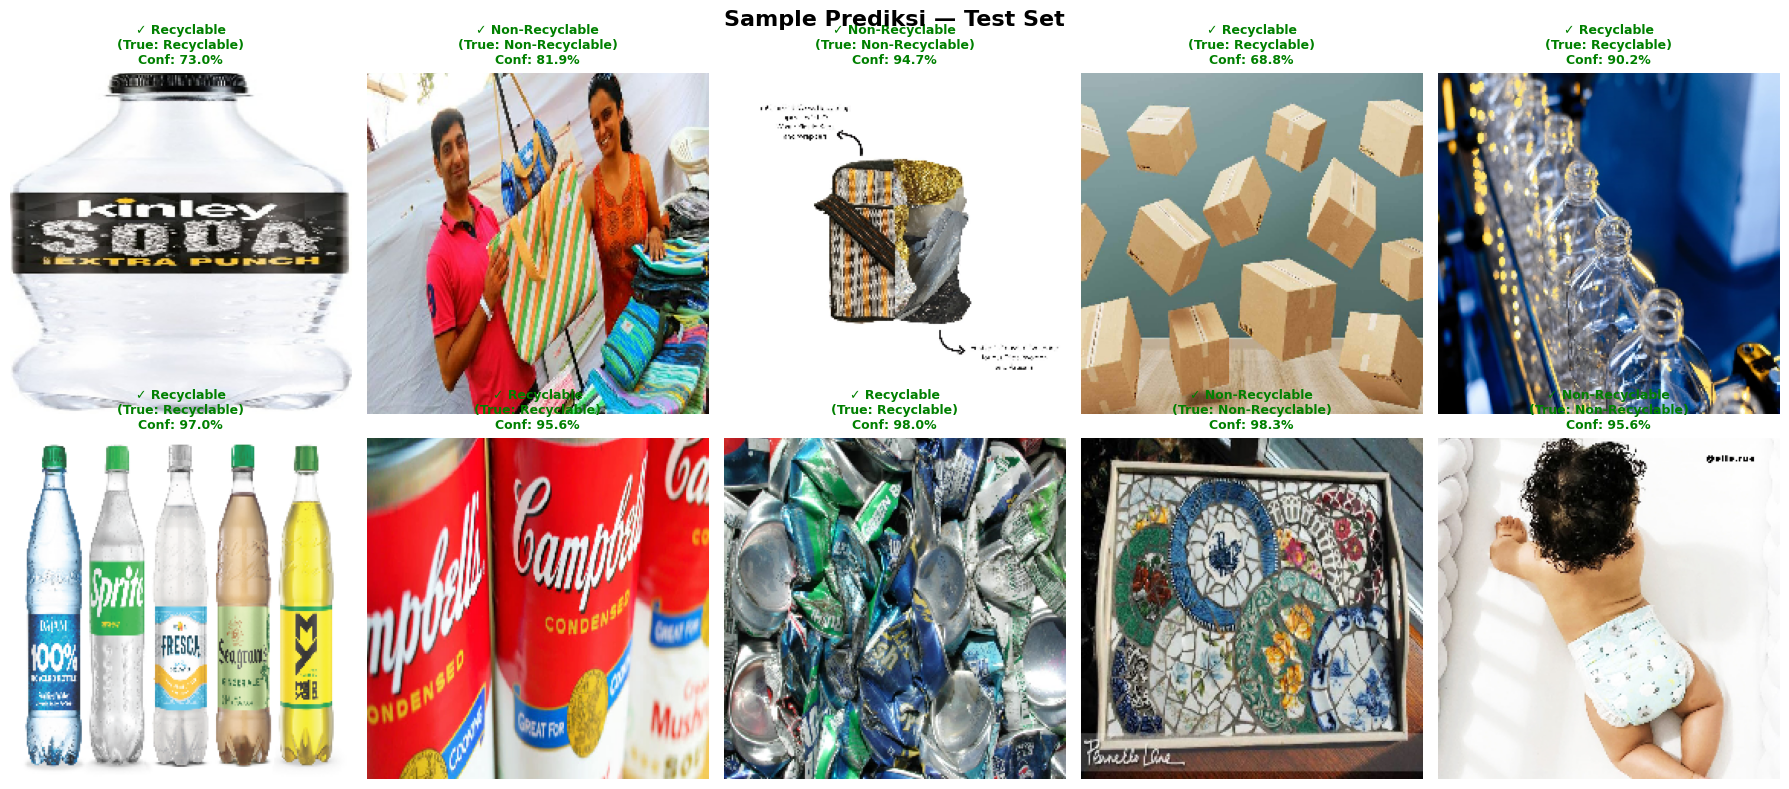

In [17]:
samples = test_df.sample(n=10, random_state=SEED)
fig, axes = plt.subplots(2, 5, figsize=(18, 8))

for idx, (_, row) in enumerate(samples.iterrows()):
    ax = axes[idx // 5, idx % 5]
    try:
        img = load_img(row['filename'], target_size=IMG_SIZE)
        img_array = img_to_array(img) / 255.0
        prob = model.predict(np.expand_dims(img_array, 0), verbose=0)[0][0]
        pred = categories[int(prob >= 0.5)]
        true = row['class']
        conf = prob if prob >= 0.5 else 1 - prob

        ax.imshow(img)
        ok = pred == true
        ax.set_title(f"{'✓' if ok else '✗'} {pred}\n(True: {true})\nConf: {conf:.1%}",
                     fontsize=9, color='green' if ok else 'red', fontweight='bold')
    except Exception:
        ax.text(0.5, 0.5, 'Error', ha='center', va='center', transform=ax.transAxes)
    ax.axis('off')

plt.suptitle('Sample Prediksi — Test Set', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('binary_prediksi_sample.png', dpi=150, bbox_inches='tight')
plt.show()

## 14. Save Model

In [18]:
# Keras format
model.save('binary_model_final.keras')
print("Disimpan: binary_model_final.keras")

# TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()
with open('binary_model.tflite', 'wb') as f:
    f.write(tflite_model)
print(f"Disimpan: binary_model.tflite ({os.path.getsize('binary_model.tflite')/1024/1024:.2f} MB)")

# Class info
class_info = {
    'task': 'binary_classification',
    'categories': categories,
    'class_indices': {'Non-Recyclable': 0, 'Recyclable': 1},
    'img_size': list(IMG_SIZE),
    'model': 'MobileNetV2 (Transfer Learning, base frozen)',
    'training': 'Single phase, ReduceLROnPlateau',
    'description': 'Klasifikasi biner: Non-Recyclable vs Recyclable'
}
with open('binary_class_info.json', 'w') as f:
    json.dump(class_info, f, indent=2)
print("Disimpan: binary_class_info.json")

Disimpan: binary_model_final.keras
INFO:tensorflow:Assets written to: C:\Users\Bisma\AppData\Local\Temp\tmpln3mp17n\assets


INFO:tensorflow:Assets written to: C:\Users\Bisma\AppData\Local\Temp\tmpln3mp17n\assets


Saved artifact at 'C:\Users\Bisma\AppData\Local\Temp\tmpln3mp17n'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  1843094904976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1843094204304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1843094204496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1843094208144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1843094208336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1843094198352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1843087968400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1843087971088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1843094204112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1843087769424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  18430

## 15. Fungsi Prediksi

In [19]:
def predict_binary(image_path, model=None, model_path='binary_model_final.keras',
                   img_size=(224, 224)):
    """
    Prediksi klasifikasi biner untuk gambar baru.

    Args:
        image_path: Path ke gambar
        model: Model Keras (opsional)
        model_path: Path ke file .keras
        img_size: Ukuran target

    Returns:
        dict hasil prediksi
    """
    cats = ['Non-Recyclable', 'Recyclable']
    if model is None:
        model = load_model(model_path)

    img = load_img(image_path, target_size=img_size)
    img_array = img_to_array(img) / 255.0
    prob = model.predict(np.expand_dims(img_array, 0), verbose=0)[0][0]
    pred_idx = int(prob >= 0.5)
    pred = cats[pred_idx]
    conf = prob if pred_idx == 1 else 1 - prob

    print(f"Prediksi  : {pred}")
    print(f"Confidence: {conf:.2%}")
    print(f"  Non-Recyclable: {1-prob:.4f}")
    print(f"  Recyclable    : {prob:.4f}")

    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.title(f"{pred} ({conf:.1%})", fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.show()

    return {'prediction': pred, 'confidence': float(conf),
            'probabilities': {'Non-Recyclable': float(1-prob), 'Recyclable': float(prob)}}

## 16. Ringkasan

In [20]:
print("=" * 60)
print("RINGKASAN — KLASIFIKASI BINER SAMPAH")
print("=" * 60)
print(f"""
Model       : MobileNetV2 Transfer Learning (base frozen)
Training    : Single phase, {EPOCHS} epoch max
LR          : {LEARNING_RATE} + ReduceLROnPlateau
Data        : {len(df)} gambar ({len(df[df['class']=='Non-Recyclable'])} NR / {len(df[df['class']=='Recyclable'])} R)
Split       : {len(train_df)} train / {len(val_df)} val / {len(test_df)} test
Accuracy    : {acc:.4f} ({acc*100:.2f}%)

Output:
  - binary_model_final.keras
  - binary_model.tflite
  - binary_class_info.json
""")
print("=" * 60)

RINGKASAN — KLASIFIKASI BINER SAMPAH

Model       : MobileNetV2 Transfer Learning (base frozen)
Training    : Single phase, 50 epoch max
LR          : 0.001 + ReduceLROnPlateau
Data        : 1309 gambar (647 NR / 662 R)
Split       : 916 train / 196 val / 197 test
Accuracy    : 0.8673 (86.73%)

Output:
  - binary_model_final.keras
  - binary_model.tflite
  - binary_class_info.json

